 loading dataset

In [1]:
import yfinance as yf

df = yf.download("MSFT", period="max")

df.to_csv("MSFT.csv")

[*********************100%***********************]  1 of 1 completed


importing liberies

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
1986-03-13,0.059125,0.061765,0.053847,0.053847,1031788800
1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000
1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200
1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400
1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400


In [18]:
df.shape

(10150, 5)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10150 entries, 1986-03-13 to 2026-06-26
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   10149 non-null  float64
 1   (High, MSFT)    10149 non-null  float64
 2   (Low, MSFT)     10149 non-null  float64
 3   (Open, MSFT)    10149 non-null  float64
 4   (Volume, MSFT)  10150 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 475.8 KB


In [14]:
df.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [13]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,10149.000000,10149.000000,10149.000000,10149.000000,1.015000e+04
mean,70.166895,70.843024,69.443582,70.160957,5.531526e+07
std,119.652135,120.727085,118.502171,119.664573,3.792884e+07
min,0.054902,0.055958,0.053847,0.053847,2.304000e+06
25%,3.905449,3.938708,3.843686,3.895944,3.025318e+07
50%,19.533541,19.728571,19.292567,19.496212,4.847290e+07
75%,47.718616,48.128129,47.174262,47.692259,6.923520e+07
max,538.658569,551.048474,537.366763,550.830186,1.031789e+09


Step 5 : Data Cleaning

In [19]:
df.isnull().sum()

Price   Ticker
Close   MSFT      1
High    MSFT      1
Low     MSFT      1
Open    MSFT      1
Volume  MSFT      0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.sort_values("Date")

In [25]:
df.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

 removing second level of columns because our project only uses Microsoft MSTF.

In [ ]:
df.columns = df.columns.get_level_values(0)
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [29]:
df.index

DatetimeIndex(['1986-03-13', '1986-03-14', '1986-03-17', '1986-03-18',
               '1986-03-19', '1986-03-20', '1986-03-21', '1986-03-24',
               '1986-03-25', '1986-03-26',
               ...
               '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25'],
              dtype='datetime64[ns]', name='Date', length=10149, freq=None)

## STEP 6 — Exploratory Data Analysis (EDA)

In [ ]:
df.dtypes       # Everything should be numeric, but the index is a datetime object. We will convert it to a numeric value.

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

we are going to use the CLose column to simply understand the closing price of stock on that day.

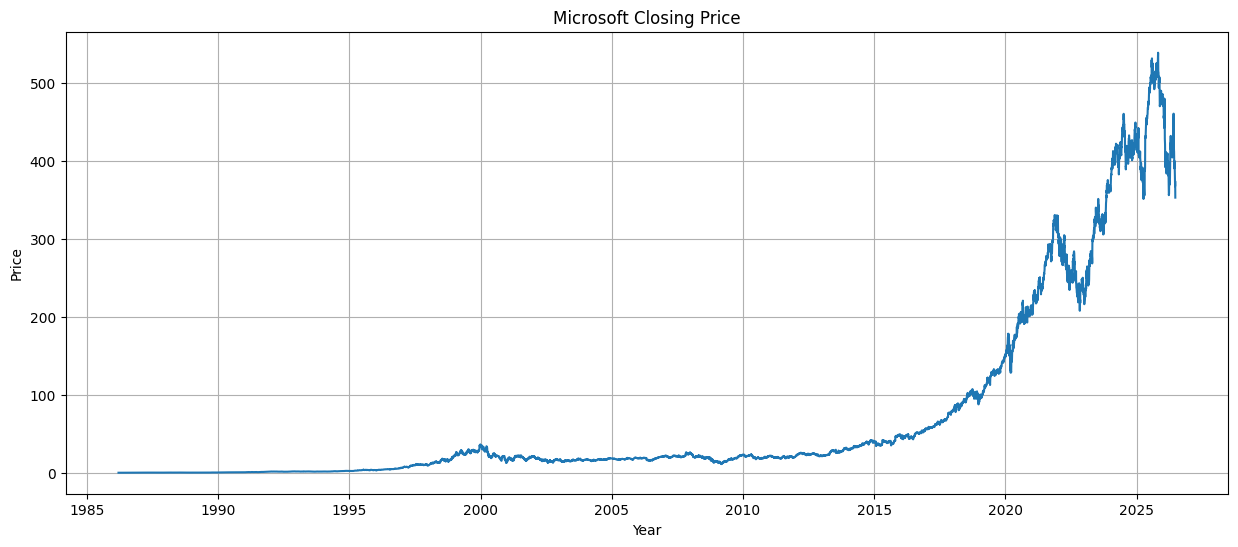

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"])

plt.title("Microsoft Closing Price")

plt.xlabel("Year")

plt.ylabel("Price")

plt.grid(True)

plt.show()

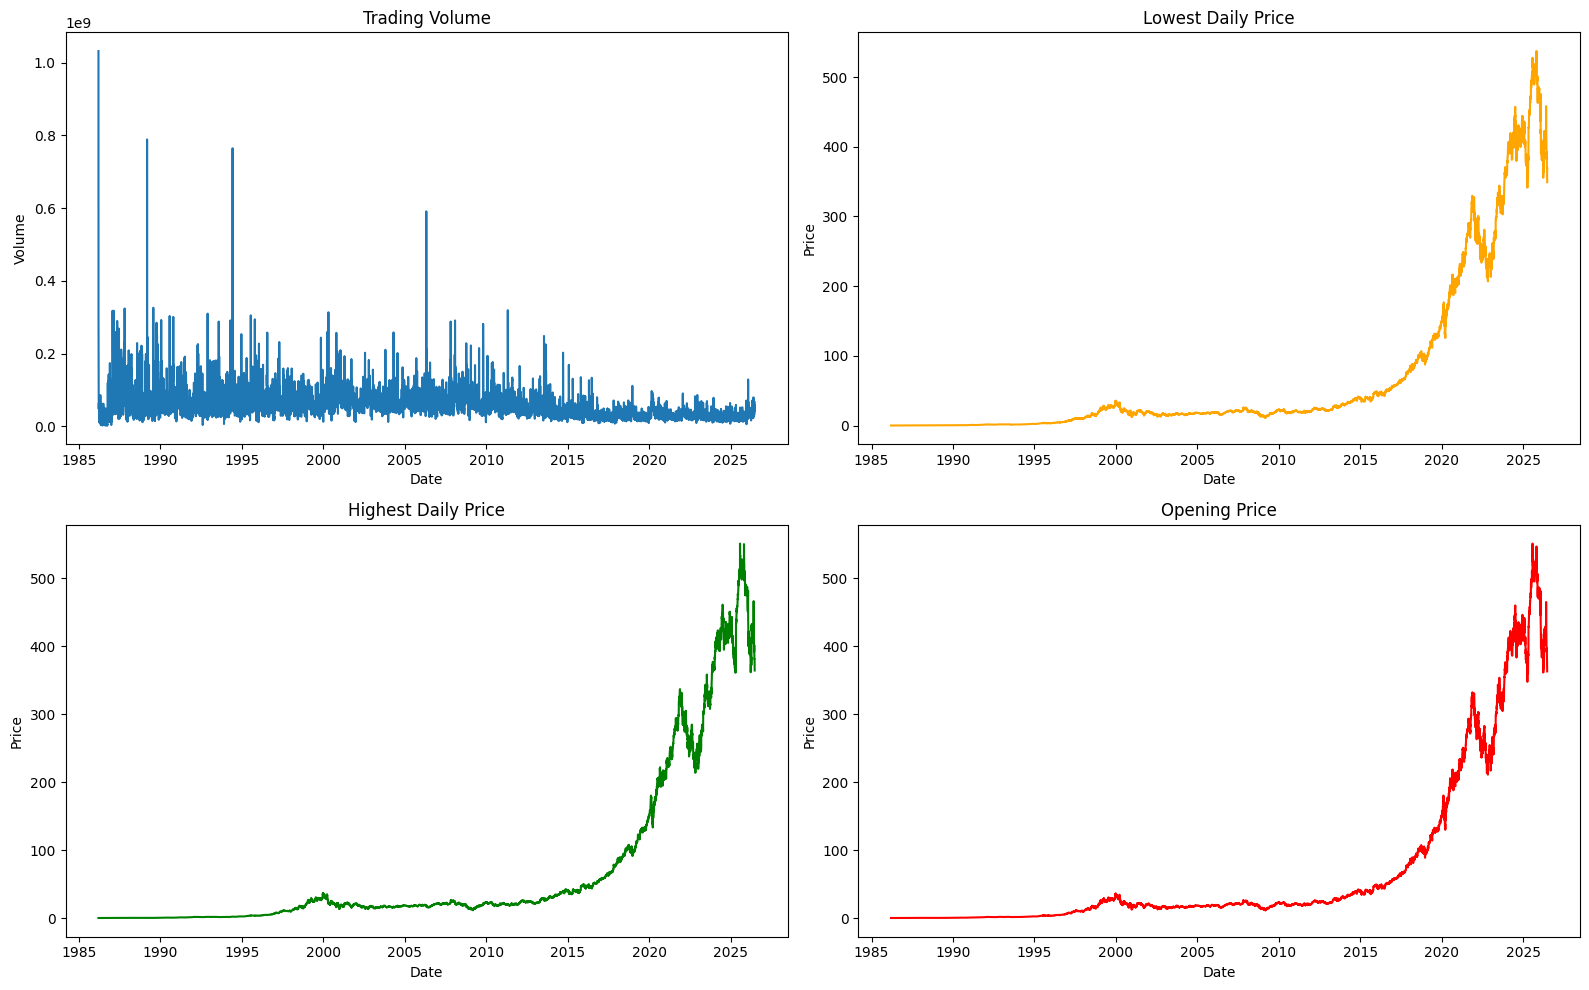

In [41]:
import matplotlib.pyplot as plt

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Trading Volume
axes[0, 0].plot(df.index, df["Volume"])
axes[0, 0].set_title("Trading Volume")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Volume")

# Lowest Daily Price
axes[0, 1].plot(df.index, df["Low"], color="orange")
axes[0, 1].set_title("Lowest Daily Price")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Price")

# Highest Daily Price
axes[1, 0].plot(df.index, df["High"], color="green")
axes[1, 0].set_title("Highest Daily Price")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Price")

# Opening Price
axes[1, 1].plot(df.index, df["Open"], color="red")
axes[1, 1].set_title("Opening Price")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Price")

# Adjust spacing between plots
plt.tight_layout()

# Display all graphs in one canvas
plt.show()

 Analysis:
- Trading volume shows occasional sharp spikes, indicating periods of high market activity.
- Open, High, and Low prices follow a very similar upward trend over time, reflecting strong long-term stock growth.
- Price volatility increases significantly in recent years, with larger fluctuations compared to earlier periods.
- Overall, the stock has experienced substantial appreciation despite short-term market corrections.

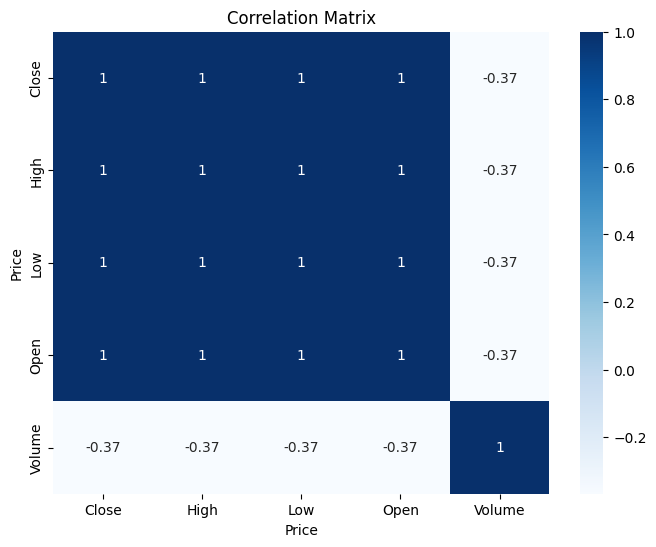

In [36]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

Observation:
- Price-related features (Open, High, Low, Close) are highly positively correlated,
- while Volume has a moderate negative correlation with prices.
- This indicates that stock prices move together, whereas trading volume follows a different pattern.

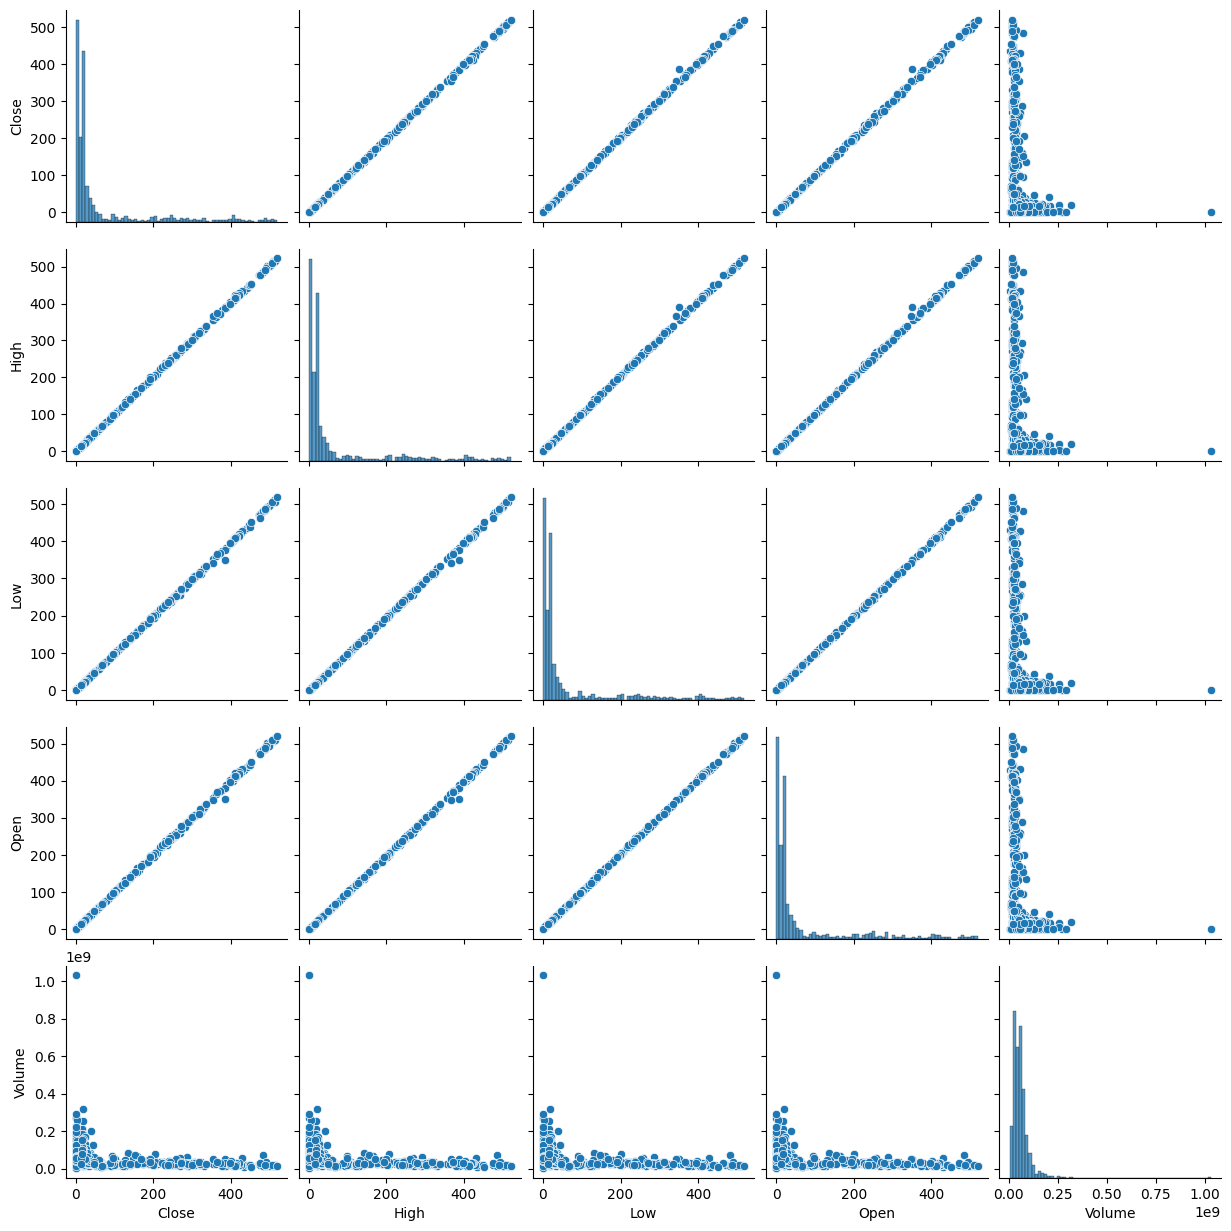

In [40]:
sns.pairplot(df.sample(1000, random_state=42))

boxplot is not applicable for this stock analysis because the outliers that appear in boxlot are not my mistake or errors those points represent real stock price movements. (like civis-19 ,AI boom, financial crises, etc)

## Feature Engineering

In [ ]:
df["Daily_Range"] = df["High"] - df["Low"]                # Daily Range
 # This tells how much the stock moved during the day.

In [46]:
df["Daily_Change"] = df["Close"] - df["Open"]             # Daily Change
# Difference between opening and closing price.

In [ ]:
df["MA_10"] = df["Close"].rolling(window=10).mean()   # 10-Day Moving Average

In [ ]:
df["MA_50"] = df["Close"].rolling(window=50).mean()     # 50-Day Moving Average

In [47]:
df.head()

Price,Close,High,Low,Open,Volume,Daily_Range,Daily_Change
Date,,,,,,,
1986-03-13,0.059125,0.061765,0.053847,0.053847,1031788800,0.007919,0.005279
1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000,0.003168,0.002111
1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200,0.001584,0.001056
1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400,0.002640,-0.001584
1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400,0.002111,-0.001056
